## Parkinson Disease Prediction using (SVC, XGBClassifier, LogisticRegression) in Sklearn, XGBoost.

### 1. Importing Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Loading Dataset

In [3]:
url = "https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/43-Parkinson%20Disease%20Prediction/parkinson_disease.csv"

In [4]:
df = pd.read_csv(url)
df.head()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


### 3. Data Preprocessing

1. Exploratory Data Analysis

In [5]:
df.shape

(756, 755)

In [6]:
df.describe()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
count,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,...,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,125.500000,0.515873,0.746284,0.700414,0.489058,323.972222,322.678571,0.006360,0.000383,0.002324,...,26.237251,22.840337,18.587888,13.872018,12.218953,12.375335,14.799230,14.751559,31.481110,0.746032
std,72.793721,0.500079,0.169294,0.069718,0.137442,99.219059,99.402499,0.001826,0.000728,0.002628,...,42.220693,32.626464,25.537464,20.046029,17.783642,16.341665,15.722502,14.432979,34.230991,0.435568
min,0.000000,0.000000,0.041551,0.543500,0.154300,2.000000,1.000000,0.002107,0.000011,0.000210,...,1.509800,1.531700,1.582900,1.747200,1.789500,1.628700,1.861700,1.955900,2.364000,0.000000
25%,62.750000,0.000000,0.762833,0.647053,0.386537,251.000000,250.000000,0.005003,0.000049,0.000970,...,2.408675,3.452800,3.354825,3.077450,2.937025,3.114375,3.665925,3.741275,3.948750,0.000000
50%,125.500000,1.000000,0.809655,0.700525,0.484355,317.000000,316.000000,0.006048,0.000077,0.001495,...,5.586300,7.062750,6.077400,4.770850,4.300450,4.741450,6.725700,7.334250,10.637250,1.000000
75%,188.250000,1.000000,0.834315,0.754985,0.586515,384.250000,383.250000,0.007528,0.000171,0.002520,...,28.958075,29.830850,21.944050,13.188000,10.876150,12.201325,21.922050,22.495175,61.125325,1.000000
max,251.000000,1.000000,0.907660,0.852640,0.871230,907.000000,905.000000,0.012966,0.003483,0.027750,...,239.788800,203.311300,121.542900,102.207000,85.571700,73.532200,62.007300,57.544300,156.423700,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


In [8]:
df.isnull().sum().sum()

np.int64(0)

2. Data Cleaning

In [9]:
df = df.groupby('id').mean().reset_index()

In [10]:
df.drop('id', axis=1, inplace=True)

In [11]:
columns = list(df.columns)
for col in columns:
    if col == 'class':
        continue

    filtered_columns = [col]
    for col1 in df.columns:
        if((col == col1) | (col == 'class')):
            continue

        val = df[col].corr(df[col1])
        if val > 0.7:
            # If the correlation between the two features is more than 0.7, remove it
            columns.remove(col1)
            continue
        else:
            filtered_columns.append(col1)
            
    df = df[filtered_columns]
df.shape

(252, 287)

3. Feature Selection

In [13]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

X = df.drop('class', axis=1)
X_norm = MinMaxScaler().fit_transform(X)
selector = SelectKBest(chi2, k=30)
selector.fit(X_norm, df['class'])
filtered_columns = selector.get_support()
filtered_data = X.loc[:, filtered_columns]
filtered_data['class'] = df['class']
df = filtered_data
df.shape

/tmp/ipykernel_1346/4169168976.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['class'] = df['class']


(252, 31)

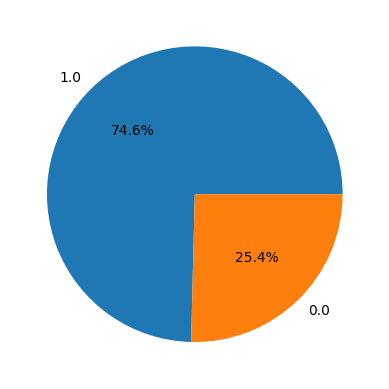

In [14]:
x = df['class'].value_counts()
plt.pie(x.values,
        labels = x.index,
        autopct='%1.1f%%')
plt.show()

In [15]:
X = df.drop('class', axis=1)
y = df['class']

4. Imbalance (imblearn)

In [16]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(sampling_strategy=1.0,
                        random_state=0)
X, y = ros.fit_resample(X, y)
X.shape, y.value_counts()

((376, 30),
 class
 1.0    188
 0.0    188
 Name: count, dtype: int64)

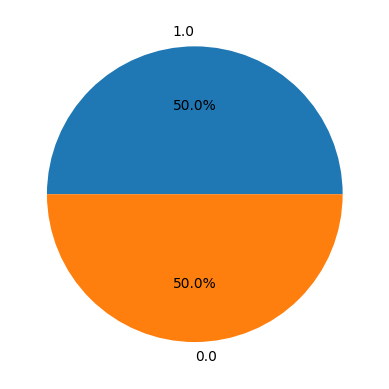

In [18]:
b = y.value_counts()
plt.pie(b.values,
        labels = x.index,
        autopct='%1.1f%%')
plt.show()

4. Train Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

### 4. Build and Fit the Models

In [29]:
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score as ras

models = [
    SVC(), XGBClassifier(), LogisticRegression()
]

train_accuracy_lst =[]

for model in range(len(models)):
    models[model].fit(X_train, y_train)

    print(f"{models[model].__class__.__name__}:")
    train_pred = models[model].predict(X_train)
    train_accuracy = ras(y_train, train_pred)
    train_accuracy_lst.append(train_accuracy)
    print(f"Model Train Accuracy: {train_accuracy:.2f}")
    print()

SVC:
Model Train Accuracy: 0.66

XGBClassifier:
Model Train Accuracy: 1.00

LogisticRegression:
Model Train Accuracy: 0.76



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
labels = ['SVC', 'XGBClassifier' ,'LogisticRegression']
accuracy = train_accuracy_lst

/tmp/ipykernel_1346/3899947575.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x= labels, y= accuracy, palette=['r', 'g', 'b'])


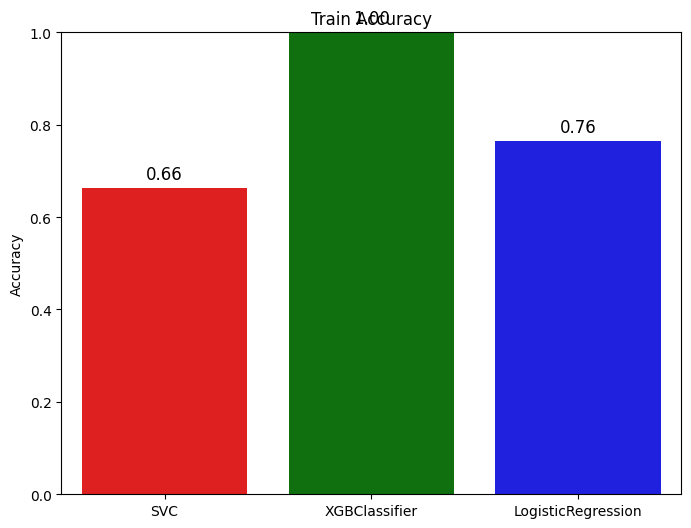

In [31]:
plt.figure(figsize=(8, 6))
bars = sns.barplot(x= labels, y= accuracy, palette=['r', 'g', 'b'])
for i, v in enumerate(accuracy):
    bars.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12)
plt.title('Train Accuracy')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.show()

### 5. Make Prediction

In [32]:
test_accuracy_lst = []
for model in range(len(models)):
    models[model].fit(X_train, y_train)

    print(f"{models[model].__class__.__name__}:")
    test_pred = models[model].predict(X_test)
    test_accuracy = ras(y_test, test_pred)
    test_accuracy_lst.append(test_accuracy)
    print(f"Model Test Accuracy: {test_accuracy:.2f}")
    print()

SVC:
Model Test Accuracy: 0.58

XGBClassifier:
Model Test Accuracy: 0.92

LogisticRegression:
Model Test Accuracy: 0.73



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
labels = ['SVC', 'XGBClassifier' ,'LogisticRegression']
accuracy = test_accuracy_lst

/tmp/ipykernel_1346/1442286058.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x= labels, y= accuracy, palette=['r', 'g', 'b'])


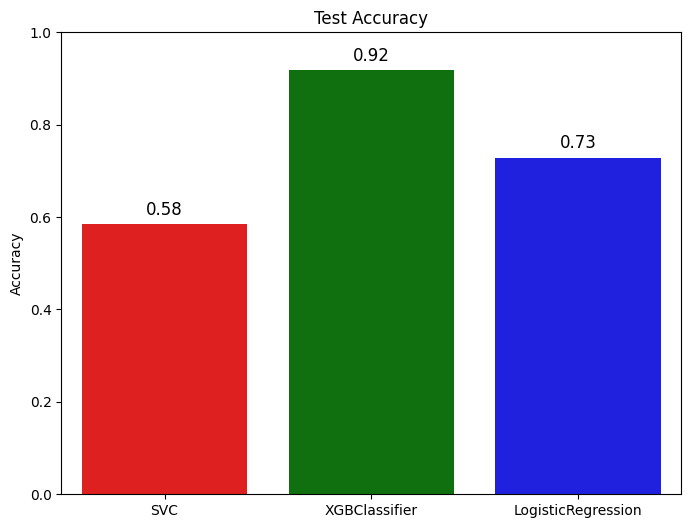

In [34]:
plt.figure(figsize=(8, 6))
bars = sns.barplot(x= labels, y= accuracy, palette=['r', 'g', 'b'])
for i, v in enumerate(accuracy):
    bars.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12)
plt.title('Test Accuracy')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.show()

### 6. Evaluate the Models


===== SVC =====
Classification report:
               precision    recall  f1-score   support

         0.0       0.57      0.49      0.52        35
         1.0       0.61      0.68      0.64        41

    accuracy                           0.59        76
   macro avg       0.59      0.58      0.58        76
weighted avg       0.59      0.59      0.59        76



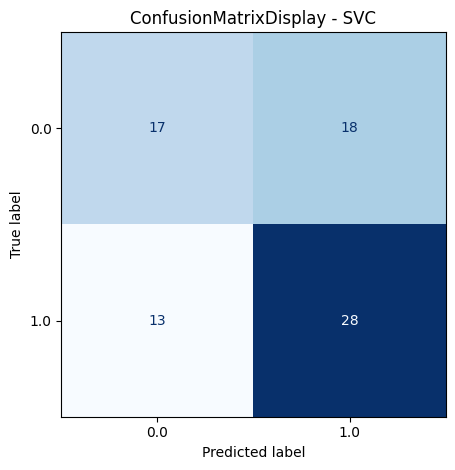


===== XGBClassifier =====
Classification report:
               precision    recall  f1-score   support

         0.0       0.94      0.89      0.91        35
         1.0       0.91      0.95      0.93        41

    accuracy                           0.92        76
   macro avg       0.92      0.92      0.92        76
weighted avg       0.92      0.92      0.92        76



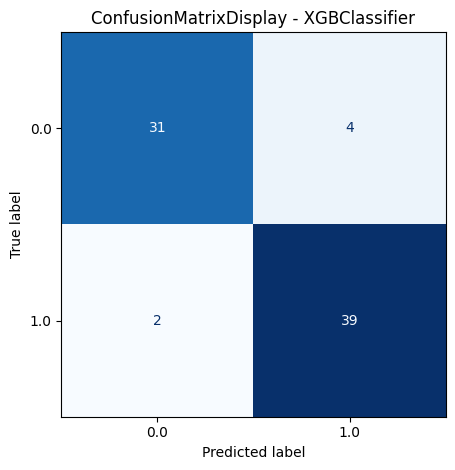


===== LogisticRegression =====
Classification report:
               precision    recall  f1-score   support

         0.0       0.76      0.63      0.69        35
         1.0       0.72      0.83      0.77        41

    accuracy                           0.74        76
   macro avg       0.74      0.73      0.73        76
weighted avg       0.74      0.74      0.73        76



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


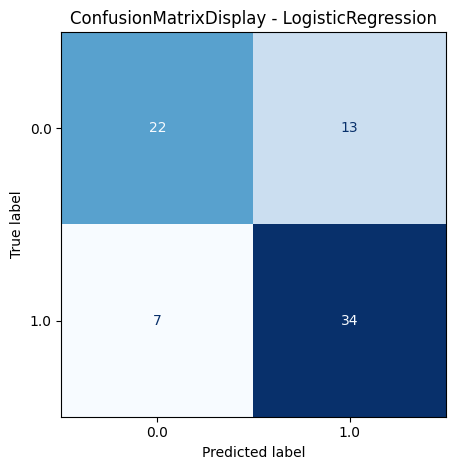

In [36]:
### Confusion Matrix (ConfusionMatrixDisplay) for each model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model_names = ['SVC', 'XGBClassifier', 'LogisticRegression']

# Plot confusion matrix for each trained model on the test set
for i, model in enumerate(models):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    display_labels = sorted(np.unique(y_test))

    print(f"\n===== {model_names[i]} =====")
    print("Classification report:\n", classification_report(y_test, y_pred))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap='Blues', colorbar=False, values_format='d')
    plt.title(f'ConfusionMatrixDisplay - {model_names[i]}')
    plt.tight_layout()
    plt.show()
